In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [48]:
df_train = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_train_eda.csv')
df_test  = pd.read_csv('D:\\repos\\ML_innovise\\data\\processed\\df_test_eda.csv')

In [49]:
df_testt = pd.read_csv(r'D:\ML_innovise\test.csv')
df_test = df_test.merge(
    df_testt,
    on = ['shop_id','item_id'],
    how = 'left'
)

In [3]:
import sys
sys.path.append("..")

In [5]:
from scripts.expanding_validator import ExpandingValidator
from scripts.expanding_window_splitter import ExpandingWindowSplitter


Тут splitter и validator, полученные методом расширяющегося окна 

In [15]:
splitter = ExpandingWindowSplitter(time_col = 'date_block_num', first_val_month=13, last_val_month=33)
model = LinearRegression()
metric = mean_squared_error
validator  = ExpandingValidator(model = model, splitter = splitter, metric = metric)

In [16]:
features =['shop_id','item_id', 'simple_category_id', 'cnt_lag_1','cnt_lag_3','cnt_lag_2','cnt_lag_12', 'cnt_rm_3','cnt_rm_6','item_avg_price_prev','date_block_num','avg_price_prev_missing']
target_col = 'item_cnt_month'

In [17]:
fold_metrics, all_preds = validator.run(df_train, features, target_col)
metrics_df = pd.DataFrame(fold_metrics).set_index('val_month')
metrics_df

,val_score
val_month,
13,0.496720
14,0.741297
15,0.429345
16,0.587572
17,0.466745
18,0.506755
19,0.631820
20,0.706302
21,0.752816


Теперь мы можем видеть, как с добавлением в обучение каждого нового месяца и валидации на нем, как изменялась валидационная метрика 

А тут мои стартовые splitter и validator, в основе которых чисто 0-32 учимся, 33 - валидируемся

In [19]:
from scripts.Splitter import Splitter

splitter = Splitter(time_col = 'date_block_num', train_end = 33)

In [51]:
from scripts.Validator import Validator
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from math import sqrt

validator = Validator(df_train, splitter, model = Ridge( alpha = 1.0), metric   = lambda y, yhat: sqrt(mean_squared_error(y, yhat)))
features =['shop_id','item_id', 'simple_category_id',  'cnt_lag_1','cnt_lag_3','cnt_lag_2','cnt_lag_12', 'cnt_rm_3','cnt_rm_6','item_avg_price_prev', 'item_price','date_block_num','avg_price_prev_missing']
result = validator.run(features, target_col = 'item_cnt_month')

print('Val RMSE:', result)

Val RMSE: {'val_score': 0.9029238390424729, 'pred_val': array([0.06991132, 0.24591715, 0.2615054 , ..., 0.199143  , 0.04869707,
       0.04869629], shape=(214200,))}


In [ ]:
# это я для проверки классов Splitter и Validator брала базовую модель Ridge - результат на кагле 1.03054
X_tr, y_tr, X_val, y_val = splitter.split(
    df_train,
    features,            
    target_col="item_cnt_month"
)
X_full = pd.concat([X_tr, X_val], axis=0)
y_full = pd.concat([y_tr, y_val], axis=0)

final_model = Ridge(alpha=1.0, random_state=42)
final_model.fit(X_full, y_full)


X_test = df_test[features]


test_pred = final_model.predict(X_test)




In [7]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  test_pred
})

submission.to_csv("submissionRidgeLopt.csv", index=False)

In [75]:
from Model import Model
 # а здесь я уже тестирую собственную модель - результат на кагле 1.17012
my_model = Model ('date_block_num', 'simple_category_id', 'item_cnt_month', ['shop_id', 'item_id'])
my_model.fit(df_train)
my_pred = my_model.predict(df_test)
my_pred = my_pred.drop_duplicates()
my_pred.head()


,shop_id,item_id,target_med,ID
0,2,30,0.184208,22987
2,2,31,0.592104,20994
4,2,32,0.184208,20995
6,2,33,0.184208,22492
8,2,38,0.184208,22491


In [76]:
my_pred['item_cnt_month'] = my_pred['target_med']


In [77]:
preds = my_pred[['ID', 'item_cnt_month']]

In [78]:
preds.to_csv("simple_submission.csv", index=False)

In [21]:
X_tr, y_tr, X_val, y_val = splitter.split(
    df_train,
    features,            
    target_col="item_cnt_month"
)
X_full = pd.concat([X_tr, X_val], axis=0)
y_full = pd.concat([y_tr, y_val], axis=0)

final_model = Ridge(alpha=1.0, random_state=42)
final_model.fit(X_full, y_full)


X_test = df_test[features]


test_pred = final_model.predict(X_test)

Тут у меня была просто космическая идея, которая к сожалению себя не оправдала: 
я решила попробовать вместо обычной цены использовать логарифмическую и попробовать взять от нее полиноммальные признаки (посколько признаки все образованы от цены - они все будут скоррелированы, поэтому я брала по одному из них, обучала ЛинРег и смотреть на скор). Вот результат моих стараний:


In [55]:
X = X_full.copy()
X['log_item_price'] = np.log1p(X['item_price'])
X['log_item_price_2'] = X['log_item_price']**2
X['log_item_price_3'] = X['log_item_price']**3



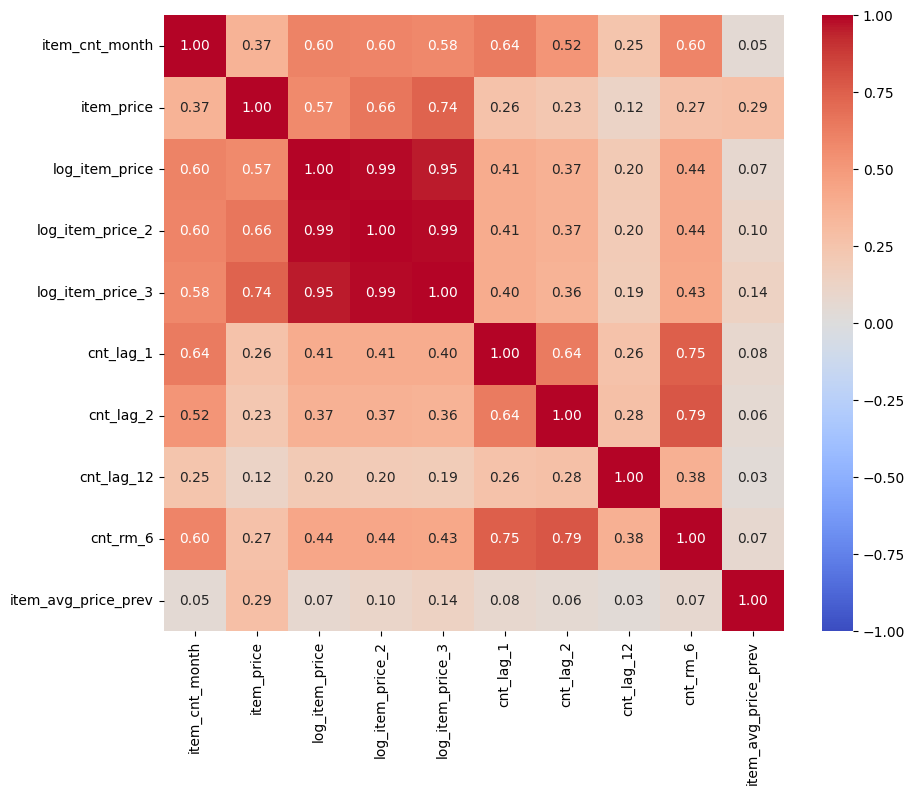

In [23]:
df_full = pd.concat([X, y_tr], axis = 1 )
cols = [
    'item_cnt_month',
    'item_price',
    'log_item_price',
    'log_item_price_2',
    'log_item_price_3',
    'cnt_lag_1',
    'cnt_lag_2',
    'cnt_lag_12',
    'cnt_rm_6',
    'item_avg_price_prev'
]

corr = df_full[cols].corr()
plt.figure(figsize = (10,8))
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.show()


Видим, что логарифмическая цена имеет гораздо больше с таргетом корреляции, чем обычная, как и полиномиальные признаки от нее.

In [ ]:
X_t = X_test.copy()
X_t['log_item_price'] = np.log1p(X_t['item_price'])
X_t['log_item_price_2'] = X_t['log_item_price']**2
X_t['log_item_price_3'] = X_t['log_item_price']**3
df_t = X_t[features]

In [109]:
modelRg1 = Ridge(alpha=1.0)
modelRg1.fit(df_train[features],y_full)
preds = modelRg1.predict(df_t)

In [110]:
submission = pd.DataFrame({
    "ID":              df_test["ID"],
    "item_cnt_month":  preds
})

submission.to_csv("submissionRidgePoly.csv", index=False)

К сожалению - скор не стал лучше, хотя эксперимент, конечно, был интересный)